In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tqdm
import sys
import os

In [3]:
sys.path.append(".")

In [4]:
from utils.datasets import SimpleSet, BerlinSparqlBenchmark
from utils.dbs import FusekiDB, QleverDB, BaseDB
from utils.datasets.base_dataset import QUERY_DIFFICULTY, QUERY_TYPE
from pathlib import Path
import numpy as np
from utils.datasets.base_dataset import DataTensor

2026-03-26 09:36:32,621 - INFO - Loading faiss.
2026-03-26 09:36:32,650 - INFO - Successfully loaded faiss.


In [5]:
powers = np.arange(0, 4)  # extend on a more powerful machine
sizes = 10**powers

In [6]:
datasets: dict[int, BerlinSparqlBenchmark] = {}
raw_sizes: dict[int, int] = {}
for power, size in zip(powers, sizes):
    print(f"Running BDSDM generation for size {size}...")
    dataset = BerlinSparqlBenchmark(base_dir=Path(f"./data/bsbm_{power}"), n=size)
    dataset.setup()
    datasets[power] = dataset
    raw_sizes[power] = dataset.get_triple_count()

2026-03-26 09:36:32,783 - INFO - BSBM dataset already exists in data/bsbm_0, skipping generation
2026-03-26 09:36:32,785 - INFO - BSBM dataset already exists in data/bsbm_1, skipping generation
2026-03-26 09:36:32,788 - INFO - BSBM dataset already exists in data/bsbm_2, skipping generation
2026-03-26 09:36:32,797 - INFO - BSBM dataset already exists in data/bsbm_3, skipping generation


Running BDSDM generation for size 1...
Running BDSDM generation for size 10...
Running BDSDM generation for size 100...
Running BDSDM generation for size 1000...


In [7]:
from sentence_transformers import SentenceTransformer

encoding_model = SentenceTransformer("all-MiniLM-L6-v2")

2026-03-26 09:36:32,945 - INFO - Use pytorch device_name: mps
2026-03-26 09:36:32,945 - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2
2026-03-26 09:36:33,176 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-03-26 09:36:33,193 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
2026-03-26 09:36:33,333 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-03-26 09:36:33,355 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-03-26 09:36:33,494 - INFO - HTTP R

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-26 09:36:34,526 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-26 09:36:34,547 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config.json "HTTP/1.1 200 OK"
2026-03-26 09:36:34,696 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-26 09:36:34,714 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transfor

In [8]:
encoded_sizes: dict[int, int] = {}
for power, size in zip(powers, sizes):
    print(f"Encoding dataset of size {size}...")
    dataset = datasets[power]
    dataset.encode(encoding_model)
    encoded_sizes[power] = dataset.get_triple_count(encoded=True)

Encoding dataset of size 1...
Encoded TTL file already exists at data/bsbm_0/dataset_encoded.nt, skipping encoding
Encoding dataset of size 10...
Encoded TTL file already exists at data/bsbm_1/dataset_encoded.nt, skipping encoding
Encoding dataset of size 100...
Encoded TTL file already exists at data/bsbm_2/dataset_encoded.nt, skipping encoding
Encoding dataset of size 1000...
Encoded TTL file already exists at data/bsbm_3/dataset_encoded.nt, skipping encoding


## BSBM queries

### Simple Use case: 
find 10 products with a specific encoded label


### Complex Use case: 
For a specific product find 10 other similar products via their product label. 


In [9]:
test_label = "house furniture storage container"
test_tensor = DataTensor.from_numpy(encoding_model.encode(test_label))

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
test_tensor.to_literal().n3()

'"{\\"data\\": [0.0019237878732383251, 0.0590696819126606, -0.06259280443191528, -0.00878896564245224, 0.08017760515213013, 0.0004897376638837159, 0.04901154339313507, -0.016156308352947235, -0.04537815973162651, 0.011929645203053951, -0.003551354631781578, -0.0034783610608428717, 0.023264393210411072, 0.024490009993314743, -0.023595614358782768, -0.0738239586353302, 0.0142268817871809, -0.00022305142192635685, -0.031117549166083336, 0.07163402438163757, -0.04559386894106865, 0.04442800208926201, 0.00043882164754904807, -0.004044309724122286, 0.05173110216856003, 0.08436276763677597, -0.028667299076914787, -0.03249424323439598, 0.05894969776272774, -0.0051073539070785046, 0.09506018459796906, -0.02917008101940155, -0.07172351330518723, 0.03642679378390312, 0.017889918759465218, 0.0777449756860733, -0.010582818649709225, -0.027199456468224525, -0.014839813113212585, 0.004996409639716148, -0.05195300653576851, -0.01563340052962303, -0.0004883771180175245, 0.012572054751217365, -0.0434229

In [11]:
base_bsbm_set = datasets[2]
db = QleverDB(
    id="test",
    base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
    dataset=base_bsbm_set,
    use_encoded_ttl=True,
)
# db = FusekiDB(
#     id="test",
#     base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
#     dataset=base_bsbm_set,
#     build_dir=Path("../jena-datatensor"),
#     do_image_build=False,
#     use_encoded_ttl=True,
# )
possible_queries = db.get_queries(test_tensor)
print(possible_queries)


{<QUERY_DIFFICULTY.EASY: 'easy'>: {<QUERY_TYPE.EMBEDDED: 'embedded'>: '\nPREFIX dt: <https://w3id.org/rdf-tensor/datatypes#>\nPREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>\nPREFIX dtf: <https://w3id.org/rdf-tensor/functions#>\nPREFIX bsbmi: <http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/>\nSELECT ?product  ?vector ?dist\nWHERE {\n?product rdf:label_embedding ?vector .\nBIND(dtf:cosineSimilarity(?vector, "{\\"data\\": [0.0019237878732383251, 0.0590696819126606, -0.06259280443191528, -0.00878896564245224, 0.08017760515213013, 0.0004897376638837159, 0.04901154339313507, -0.016156308352947235, -0.04537815973162651, 0.011929645203053951, -0.003551354631781578, -0.0034783610608428717, 0.023264393210411072, 0.024490009993314743, -0.023595614358782768, -0.0738239586353302, 0.0142268817871809, -0.00022305142192635685, -0.031117549166083336, 0.07163402438163757, -0.04559386894106865, 0.04442800208926201, 0.00043882164754904807, -0.004044309724122286, 0.05173110216856003, 0.08436

In [12]:
print(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])


PREFIX dt: <https://w3id.org/rdf-tensor/datatypes#>
PREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX dtf: <https://w3id.org/rdf-tensor/functions#>
PREFIX bsbmi: <http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/>
SELECT ?product  ?vector ?dist
WHERE {
?product rdf:label_embedding ?vector .
BIND(dtf:cosineSimilarity(?vector, "{\"data\": [0.0019237878732383251, 0.0590696819126606, -0.06259280443191528, -0.00878896564245224, 0.08017760515213013, 0.0004897376638837159, 0.04901154339313507, -0.016156308352947235, -0.04537815973162651, 0.011929645203053951, -0.003551354631781578, -0.0034783610608428717, 0.023264393210411072, 0.024490009993314743, -0.023595614358782768, -0.0738239586353302, 0.0142268817871809, -0.00022305142192635685, -0.031117549166083336, 0.07163402438163757, -0.04559386894106865, 0.04442800208926201, 0.00043882164754904807, -0.004044309724122286, 0.05173110216856003, 0.08436276763677597, -0.028667299076914787, -0.03249424323439598, 0.05894969776272774, -

In [13]:
with db:
    possible_queries = db.get_queries(test_tensor)
    results = db.query(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])
results

2026-03-26 09:36:36,325 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-03-26 09:36:36,326 - WARNING - DB directory scratch/bsbm/bsbm_2/qlever_db already exists, removing locks if any
2026-03-26 09:36:36,326 - INFO - Stopping server with container name qlever_benchmarks_test


2026-03-26 09:36:36,391 - ERROR - Command failed with return code 1
2026-03-26 09:36:36,431 - INFO - Starting QLever server with container name qlever_benchmarks_test on port 5031
2026-03-26 09:36:36,433 - INFO - Running command: docker run --name qlever_benchmarks_test -e UID=501 -e GID=220 -p 5031:5030 -v /Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/benchmarks/scratch/bsbm/bsbm_2/qlever_db:/data -w /data  qlever:tensors 'qlever-server -o -i test --port 5030 -k 0'
2026-03-26 09:36:40,499 - INFO - Server is up and responding to queries
2026-03-26 09:36:40,736 - INFO - Stopping server with container name qlever_benchmarks_test


,product,vector,dist
0,bsbmi:ProductFeature553,"{""Data"": [0.009423847310245037, -0.01557747554...",0.3165358901024
1,bsbmi:ProductFeature288,"{""Data"": [0.010077591054141521, -0.07332565635...",0.2936042249203
2,bsbmi:ProductFeature911,"{""Data"": [0.0399559922516346, 0.04019024968147...",0.2867617607117
3,bsbmi:ProductFeature806,"{""Data"": [0.06109052151441574, -0.086534291505...",0.2798336446285
4,bsbmi:ProductFeature871,"{""Data"": [0.018030863255262375, 0.051510427147...",0.2643584311008
5,bsbmi:dataFromProducer2/Product85,"{""Data"": [0.03998035192489624, 0.0118160368874...",0.263692766428
6,bsbmi:ProductType15,"{""Data"": [-0.07872356474399567, 0.087168984115...",0.2601970136166
7,bsbmi:dataFromProducer1/Product3,"{""Data"": [-0.0035400420892983675, 0.0261042360...",0.259198397398
8,bsbmi:ProductFeature580,"{""Data"": [-0.05134187638759613, -0.03562515974...",0.2406378686428
9,bsbmi:ProductFeature660,"{""Data"": [0.07709012180566788, 0.0770644396543...",0.2402603328228


In [14]:
with db:
    count=db.query("SELECT (COUNT(*) AS ?count) WHERE { ?s ?p ?o }")
print(count)

2026-03-26 09:36:42,108 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-03-26 09:36:42,111 - WARNING - DB directory scratch/bsbm/bsbm_2/qlever_db already exists, removing locks if any
2026-03-26 09:36:42,112 - INFO - Stopping server with container name qlever_benchmarks_test
2026-03-26 09:36:42,162 - ERROR - Command failed with return code 1
2026-03-26 09:36:42,196 - INFO - Starting QLever server with container name qlever_benchmarks_test on port 5031
2026-03-26 09:36:42,197 - INFO - Running command: docker run --name qlever_benchmarks_test -e UID=501 -e GID=220 -p 5031:5030 -v /Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/benchmarks/scratch/bsbm/bsbm_2/qlever_db:/data -w /data  qlever:tensors 'qlever-server -o -i test --port 5030 -k 0'
2026-03-26 09:36:45,227 - INFO - Server is up and responding to queries
2026-03-26 09:36:45,235 - INFO - Stopping server with container name qlever_benchmarks_test


   count
0  42417


In [ ]:
import time

with db:
    possible_queries = db.get_queries(test_tensor)
    timings = []
    for _ in tqdm.tqdm(range(10)):
        start_time = time.time()
        results = db.query_auto(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])
        elapsed_time = time.time() - start_time
        timings.append(elapsed_time)
print("Median elapsed time:", np.median(timings))
results

2026-03-26 09:36:46,541 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-03-26 09:36:46,542 - WARNING - DB directory scratch/bsbm/bsbm_2/qlever_db already exists, removing locks if any
2026-03-26 09:36:46,543 - INFO - Stopping server with container name qlever_benchmarks_test
2026-03-26 09:36:46,591 - ERROR - Command failed with return code 1
2026-03-26 09:36:46,620 - INFO - Starting QLever server with container name qlever_benchmarks_test on port 5031
2026-03-26 09:36:46,621 - INFO - Running command: docker run --name qlever_benchmarks_test -e UID=501 -e GID=220 -p 5031:5030 -v /Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/benchmarks/scratch/bsbm/bsbm_2/qlever_db:/data -w /data  qlever:tensors 'qlever-server -o -i test --port 5030 -k 0'
2026-03-26 09:36:49,659 - INFO - Server is up and responding to queries
100%|██████████| 10/10 [00:00<00:00, 42.28it/s]
2026-03-26 09:36:49,898 - INFO - Stopping server with container name qlever_benchmarks_test


Median elapsed time: 0.006683945655822754


,product,vector,dist
0,bsbmi:ProductFeature553,"{""Data"": [0.009423847310245037, -0.01557747554...",0.3165358901024
1,bsbmi:ProductFeature288,"{""Data"": [0.010077591054141521, -0.07332565635...",0.2936042249203
2,bsbmi:ProductFeature911,"{""Data"": [0.0399559922516346, 0.04019024968147...",0.2867617607117
3,bsbmi:ProductFeature806,"{""Data"": [0.06109052151441574, -0.086534291505...",0.2798336446285
4,bsbmi:ProductFeature871,"{""Data"": [0.018030863255262375, 0.051510427147...",0.2643584311008
5,bsbmi:dataFromProducer2/Product85,"{""Data"": [0.03998035192489624, 0.0118160368874...",0.263692766428
6,bsbmi:ProductType15,"{""Data"": [-0.07872356474399567, 0.087168984115...",0.2601970136166
7,bsbmi:dataFromProducer1/Product3,"{""Data"": [-0.0035400420892983675, 0.0261042360...",0.259198397398
8,bsbmi:ProductFeature580,"{""Data"": [-0.05134187638759613, -0.03562515974...",0.2406378686428
9,bsbmi:ProductFeature660,"{""Data"": [0.07709012180566788, 0.0770644396543...",0.2402603328228


## Try some timings!

In [16]:
import timeit
import pandas as pd


def test_db(
    power: int,
    size: int,
    db: BaseDB,
    difficulty=QUERY_DIFFICULTY.EASY,
    query_type=QUERY_TYPE.EMBEDDED,
    repetitions=128,
) -> pd.DataFrame:
    timings = []
    if query_type not in db.get_available_query_types():
        print(f"Query type {query_type} not available for {db.name}, skipping.")
        return pd.DataFrame()
    test_queries = db.get_queries(
        embedding=test_tensor,
    )
    q = test_queries[difficulty][query_type]
    for i in tqdm.tqdm(
        range(repetitions),
        desc=f"Timing for size {size}, difficulty {difficulty.value}, query type {query_type.value}, db {db.name}",
    ):
        start_time = timeit.default_timer()
        try:
            results = db.raw_query(q)
            assert results is not None and len(results.bindings) > 0, (
                "Query returned no results"
            )
        except Exception as e:
            print(f"Error occurred while querying {db.name}: {e}")
            break
        end_time = timeit.default_timer()
        elapsed_time = end_time - start_time
        timings.append(
            {
                "size": encoded_sizes[power],
                "power": power,
                "estimated_size": size,
                "elapsed_time": elapsed_time,
                "rep": i,
                "engine": db.name,
                "difficulty": difficulty.value,
                "query_type": query_type.value,
            }
        )
        if elapsed_time > 30:
            print(
                f"Warning: Query took {elapsed_time:.2f} seconds on {db.name} for size {size}, difficulty {difficulty.value}, query type {query_type.value}. Will cancel."
            )
            break
    return pd.DataFrame(timings)


timings_df = pd.DataFrame()
for power, size in zip(powers, sizes):
    difficulties = [
        # QUERY_DIFFICULTY.HARD,
        QUERY_DIFFICULTY.EASY,
    ]
    if power > 1:
        difficulties = [QUERY_DIFFICULTY.EASY]
    print(f"Running BDSDM timing for size {size}...")
    dataset = datasets[power]
    dbs: list[BaseDB] = [
        QleverDB(
            id="timing-qlever",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
        ),
        FusekiDB(
            id="timing-fuseki",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            build_dir=Path("../jena-datatensor"),
            dataset=dataset,
            use_encoded_ttl=True,
        ),
    ]
    for db in dbs:
        for difficulty in difficulties:
            repetitions = 128 if difficulty == QUERY_DIFFICULTY.EASY else 16
            for query_type in [
                # QUERY_TYPE.INDEX,
                QUERY_TYPE.EMBEDDED,
            ]:
                print(
                    f"Testing {db.name} with difficulty {difficulty.value} and query type {query_type.value}..."
                )
                with db:
                    db_timings = test_db(
                        power=power,
                        size=size,
                        db=db,
                        difficulty=difficulty,
                        query_type=query_type,
                        repetitions=repetitions,
                    )
                    timings_df = pd.concat([timings_df, db_timings], ignore_index=True)


2026-03-26 09:36:51,210 - INFO - Loading dataset into QLever server from data/bsbm_0/dataset.nt
2026-03-26 09:36:51,211 - WARNING - DB directory scratch/bsbm/bsbm_0/qlever_db already exists, removing locks if any
2026-03-26 09:36:51,211 - INFO - Stopping server with container name qlever_benchmarks_timing-qlever
2026-03-26 09:36:51,239 - ERROR - Command failed with return code 1
2026-03-26 09:36:51,269 - INFO - Starting QLever server with container name qlever_benchmarks_timing-qlever on port 5031
2026-03-26 09:36:51,270 - INFO - Running command: docker run --name qlever_benchmarks_timing-qlever -e UID=501 -e GID=220 -p 5031:5030 -v /Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/benchmarks/scratch/bsbm/bsbm_0/qlever_db:/data -w /data  qlever:tensors 'qlever-server -o -i timing-qlever --port 5030 -k 0'


Running BDSDM timing for size 1...
Testing QLever (Extended) with difficulty easy and query type embedded...


KeyboardInterrupt: 

In [ ]:
db.get_queries(test_tensor)[QUERY_DIFFICULTY.EASY].keys()

dict_keys([<QUERY_TYPE.EMBEDDED: 'embedded'>, <QUERY_TYPE.TWO_STAGE: 'two_stage'>])

In [ ]:
timings_df.to_csv("./scratch/bdsdm_timings.csv", index=False)
timings_df["engine"].unique()

<StringArray>
['QLever (Extended)', 'FusekiDB + RDFTensor']
Length: 2, dtype: str

In [ ]:
engines = timings_df["engine"].unique()
difficulties = timings_df["difficulty"].unique()

In [ ]:
groupings = timings_df.groupby(["size", "engine", "difficulty", "query_type"])[
    "elapsed_time"
]
quantiles = [0.05, 0.95]
median_timings = groupings.median().reset_index()
quantile_timings = groupings.quantile(quantiles).unstack().reset_index()

In [ ]:
median_timings

,size,engine,difficulty,query_type,elapsed_time
0,2418,FusekiDB + RDFTensor,easy,embedded,0.014139
1,2418,QLever (Extended),easy,embedded,0.004390
2,5595,FusekiDB + RDFTensor,easy,embedded,0.021251
3,5595,QLever (Extended),easy,embedded,0.003695
4,42417,FusekiDB + RDFTensor,easy,embedded,0.033327
5,42417,QLever (Extended),easy,embedded,0.004428
6,383751,FusekiDB + RDFTensor,easy,embedded,0.109064
7,383751,QLever (Extended),easy,embedded,0.004971


In [ ]:
colors = {eng: color for eng, color in zip(engines, ["C0", "C1", "C2", "C3", "C4"])}
colors

{'QLever (Extended)': 'C0', 'FusekiDB + RDFTensor': 'C1'}

/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_66153/3980750697.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(
/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_66153/3980750697.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


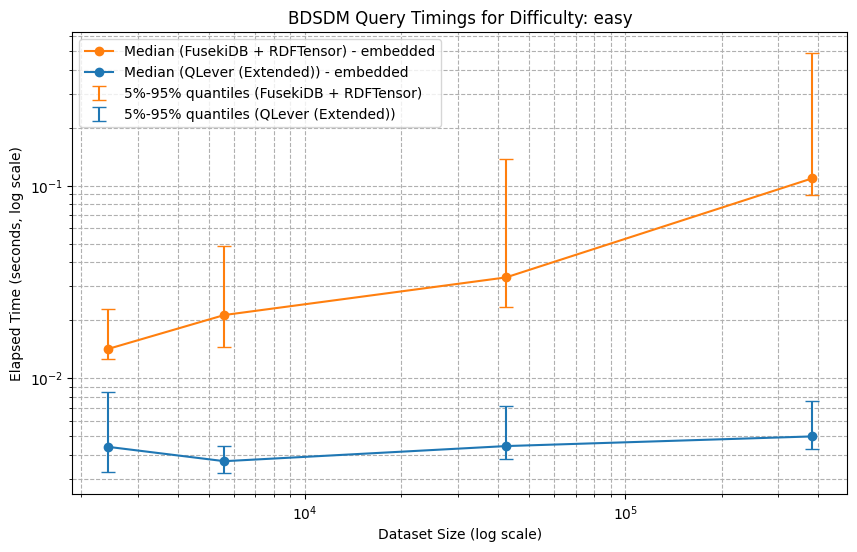

In [ ]:
import matplotlib.pyplot as plt


# plot the timings as double-log plot with error bars for the 5% and 95% quantiles
def plot_timings(ax, median_timings, quantile_timings, engine, difficulty):
    for query_type in QUERY_TYPE:
        for engine in median_timings["engine"].unique():
            engine_median = median_timings[
                (median_timings["query_type"] == query_type.value)
                & (median_timings["difficulty"] == difficulty)
                & (median_timings["engine"] == engine)
            ]
            engine_quantiles = quantile_timings[
                (quantile_timings["query_type"] == query_type.value)
                & (quantile_timings["difficulty"] == difficulty)
                & (quantile_timings["engine"] == engine)
            ]
            if engine_median.empty or engine_quantiles.empty:
                continue
            # index are dashed, embedded are solid
            linestyle = "--" if query_type == QUERY_TYPE.INDEX else "-"
            ax.plot(
                engine_median["size"],
                engine_median["elapsed_time"],
                "o-",
                linestyle=linestyle,
                label=f"Median ({engine}) - {query_type.value}",
                color=colors[engine],
            )
            ax.errorbar(
                engine_median["size"],
                engine_median["elapsed_time"],
                yerr=[
                    engine_median["elapsed_time"] - engine_quantiles[0.05],
                    engine_quantiles[0.95] - engine_median["elapsed_time"],
                ],
                barsabove=True,
                capsize=5,
                fmt="none",
                label=f"5%-95% quantiles ({engine})",
                color=colors[engine],
            )


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, median_timings, quantile_timings, engines, difficulty)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Dataset Size (log scale)")
    ax.set_ylabel("Elapsed Time (seconds, log scale)")
    ax.set_title(f"BDSDM Query Timings for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bdsdm_timings.png")
plt.show()

In [ ]:
import numpy as np
import faiss

N = 10000
quantizer = faiss.IndexFlatIP(N)  # the other index
index = faiss.IndexIVFFlat(quantizer, N, 100)
data = []
for i in range(N):
    vec = np.zeros(N, dtype=np.float32) + 0.001 * np.random.rand(N)
    vec[i] = 1.0
    data.append(vec)
data = np.array(data)
index.train(data)
index.add(data)

In [ ]:
query_vec = np.zeros(N, dtype=np.float32)
query_vec[12] = 1.0
D, I = index.search(query_vec[None, :], 100)
print("Distances:", D)
print("Indices:", I)

Distances: [[0.00334409 2.0013294  2.0013456  2.0013587  2.0013864  2.0013967
  2.0014403  2.001448   2.0014603  2.001493   2.001494   2.0014982
  2.0015168  2.0015302  2.0015624  2.0015633  2.0015686  2.00162
  2.001625   2.0016418  2.0016465  2.0016527  2.0016606  2.001687
  2.0016973  2.0017102  2.0017114  2.0017352  2.0017376  2.0017383
  2.001806   2.0018067  2.0018392  2.0018516  2.0018554  2.0018783
  2.0018864  2.0018933  2.0018942  2.0019245  2.0019312  2.0019438
  2.0019631  2.001964   2.0019727  2.0020366  2.0020516  2.002059
  2.0020745  2.002081   2.0020893  2.002124   2.0021417  2.0021632
  2.00219    2.0021968  2.0022275  2.00223    2.0022318  2.002242
  2.0022457  2.002248   2.0022888  2.0022984  2.0022998  2.0023062
  2.0023408  2.00236    2.0023608  2.0023642  2.0023665  2.0023918
  2.002412   2.002434   2.0024385  2.0024424  2.0024424  2.0025005
  2.0025434  2.002547   2.0025501  2.0025568  2.0025716  2.0025926
  2.002597   2.0026052  2.002614   2.0026255  2.0026276 